# TESI DI LAUREA 
## Cavallari Anna matr.1099291

## EDA & Preprocessing 

Questo notebook illustra un flusso completo di **Exploratory Data Analysis (EDA)** e **preprocessing** sul dataset COMPAS.

### Struttura del notebook
1. set up e caricamento iniziare dei dati
2. prima esplorazione dei dataset
3. controllo duplicati
4. selezione variabili utili
5. gestione valori mancanti
6. filtro ProPubblica
EDA
7. Analisi esplorativa variabili numeriche
    7.1 boxplot outlier
8. Analisi esplorativa variabili categoriche
9. Ricerca categorie rare
10. rilevamento outlier
11. Analisi delle correlazioni
12. EDA per variabile target
13. relazione variabile target e altre variabili
    13.1 categoriche
    13.2 numeriche
14. analisi variabile target e variabili sensibili race e sex
15. analisi score compas e gruppi sensibili race e sex
16. riassunto finale

## 1. Setup e caricamento iniziale dei dati

In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


DOWNLOAD DATASET COMPAS

In [93]:
import os
import pandas as pd

file_path = "ds/compas-scores-two-years (1).csv"

df_raw = pd.read_csv(file_path)

print(f"Dataset caricato: {df_raw.shape[0]:,} righe × {df_raw.shape[1]} colonne")
df_raw.head()

Dataset caricato: 7,214 righe × 53 colonne


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


Subito dopo viene stampata la dimensione del dataset, cioè:

- numero di righe
- numero di colonne

e viene visualizzata un’anteprima delle prime osservazioni.

piccolo check

In [94]:
df_raw.shape
df_raw.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')

- quante osservazioni sono presenti
- quali variabili sono disponibili

___
## 2. Prima esplorazione del dataset

In [95]:
df_raw.info()
df_raw.describe()


<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,7192.000,7214.000,2316.000,0.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000
mean,5501.256,34.818,0.067,4.510,0.091,0.109,3.472,3.305,57.731,0.481,20.269,NaN,0.114,4.510,3.692,3.472,11.465,553.437,0.383,0.451
std,3175.707,11.889,0.474,2.856,0.485,0.502,4.883,75.810,329.740,0.500,74.872,NaN,0.317,2.856,2.510,4.883,46.955,399.021,0.486,0.498
min,1.000,18.000,0.000,1.000,0.000,0.000,0.000,-414.000,0.000,0.000,-1.000,NaN,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000
25%,2735.250,25.000,0.000,2.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,NaN,0.000,2.000,1.000,0.000,0.000,148.250,0.000,0.000
50%,5509.500,31.000,0.000,4.000,0.000,0.000,2.000,-1.000,1.000,0.000,0.000,NaN,0.000,4.000,3.000,2.000,0.000,530.500,0.000,0.000
75%,8246.500,42.000,0.000,7.000,0.000,0.000,5.000,0.000,2.000,1.000,1.000,NaN,0.000,7.000,5.000,5.000,1.000,914.000,1.000,1.000
max,11001.000,96.000,20.000,10.000,13.000,17.000,38.000,1057.000,9485.000,1.000,993.000,NaN,1.000,10.000,10.000,38.000,937.000,1186.000,1.000,1.000


Con info() si osserva:

- se una colonna è numerica o categorica
- quante osservazioni non nulle ha
- se ci sono possibili problemi di formattazione

Con describe() si osservano per le variabili numeriche:

- media
- deviazione standard
- minimi e massimi
- quartili

In [96]:
df_raw.describe(include="all")


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214,7214,7214,7214,7214,7214,7214.000,7214,7214,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,6907,6907,7192,6055,1137,7192.000,7214,7185,7214.000,3471,3471,2316.000,3471,3413,2316,2316,0.000,7214.000,819,819,819,819,7214,7214.000,7214,7214,7214,7214.000,7214,7214,6978,6978,7214.000,7214.000,7214.000,7214.000,7214.000
unique,NaN,7158,2800,3950,690,2,5452,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN,6907,6880,7192,927,580,NaN,2,437,NaN,3471,10,NaN,1075,340,972,938,NaN,NaN,819,9,570,83,1,NaN,3,690,1,NaN,3,690,1156,1169,NaN,NaN,NaN,NaN,NaN
top,NaN,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,NaN,25 - 45,African-American,NaN,NaN,NaN,NaN,NaN,NaN,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,NaN,F,Battery,NaN,13009779CF10A,(M1),NaN,2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,NaN,NaN,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,NaN,Low,2013-02-20,Risk of Violence,NaN,Low,2013-02-20,2014-01-22,2020-01-01,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,149,83,32,5819,5,NaN,4109,3696,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,26,9,NaN,4666,1156,NaN,1,1201,NaN,12,258,9,9,NaN,NaN,1,344,6,329,7214,NaN,3897,32,7214,NaN,4761,32,20,61,NaN,NaN,NaN,NaN,NaN
mean,5501.256,NaN,NaN,NaN,NaN,NaN,NaN,34.818,NaN,NaN,0.067,4.510,0.091,0.109,3.472,3.305,NaN,NaN,NaN,NaN,NaN,57.731,NaN,NaN,0.481,NaN,NaN,20.269,NaN,NaN,NaN,NaN,NaN,0.114,NaN,NaN,NaN,NaN,NaN,4.510,NaN,NaN,NaN,3.692,NaN,NaN,NaN,NaN,3.472,11.465,553.437,0.383,0.451
std,3175.707,NaN,NaN,NaN,NaN,NaN,NaN,11.889,NaN,NaN,0.474,2.856,0.485,0.502,4.883,75.810,NaN,NaN,NaN,NaN,NaN,329.740,NaN,NaN,0.500,NaN,NaN,74.872,NaN,NaN,NaN,NaN,NaN,0.317,NaN,NaN,NaN,NaN,NaN,2.856,NaN,NaN,NaN,2.510,NaN,NaN,NaN,NaN,4.883,46.955,399.021,0.486,0.498
min,1.000,NaN,NaN,NaN,NaN,NaN,NaN,18.000,NaN,NaN,0.000,1.000,0.000,0.000,0.000,-414.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000
25%,2735.250,NaN,NaN,NaN,NaN,NaN,NaN,25.000,NaN,NaN,0.000,2.000,0.000,0.000,0.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,148.250,0.000,0.000
50%,5509.500,NaN,NaN,NaN,NaN,NaN,NaN,31.000,NaN,NaN,0.000,4.000,0.000,0.000,2.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,4.000,NaN,NaN,NaN,3.000,NaN,NaN,NaN,NaN,2.000,0.000,530.500,0.000,0.000
75%,8246.500,NaN,NaN,NaN,NaN,NaN,NaN,42.000,NaN,NaN,0.000,7.000,0.000,0.000,5.000,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,1.000,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,5.000,NaN,NaN,NaN,NaN,5.000,1.000,914.000,1.000,1.000


Con describe(include="all") si estende l’analisi anche alle categoriche:

- numero di valori osservati
- categoria più frequente
- frequenza della modalità

In [97]:
df_raw.isnull().sum().sort_values(ascending=False)


violent_recid              7214
vr_charge_degree           6395
vr_case_number             6395
vr_offense_date            6395
vr_charge_desc             6395
c_arrest_date              6077
r_jail_out                 4898
r_jail_in                  4898
r_days_from_arrest         4898
r_charge_desc              3801
r_offense_date             3743
r_case_number              3743
r_charge_degree            3743
c_offense_date             1159
c_jail_out                  307
days_b_screening_arrest     307
c_jail_in                   307
out_custody                 236
in_custody                  236
c_charge_desc                29
c_days_from_compas           22
c_case_number                22
v_type_of_assessment          0
type_of_assessment            0
decile_score.1                0
v_decile_score                0
v_score_text                  0
v_screening_date              0
screening_date                0
priors_count.1                0
start                         0
end     

Con isnull().sum() viene controllata la presenza di missing values in ciascuna colonna. in ordine ascendente ossia dal più alto al nullo

mostrare che ho analizzato la struttura del dataset prima della pulizia.

In [98]:
df_raw.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.000,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.000,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.000,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.000,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.000,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.000,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,brada

___
## 3. controllo duplicati

In [99]:
df_nodup = df_raw.drop_duplicates().copy()

before = len(df_raw)
after = len(df_nodup)

print(f"Duplicati rimossi: {before - after} righe")
print(f"Shape dopo rimozione duplicati: {df_nodup.shape}")


Duplicati rimossi: 0 righe
Shape dopo rimozione duplicati: (7214, 53)


Questo passaggio serve a evitare che eventuali osservazioni ripetute influenzino in modo scorretto l’analisi descrittiva e le analisi successive.
La rimozione dei duplicati migliora la qualità del dataset perché evita di sovrarappresentare alcuni casi.

___
## 4.selezioni varibili utili

In [100]:
cols = [
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "days_b_screening_arrest",
    "c_charge_degree",
    "is_recid",
    "score_text",
    "decile_score",
    "two_year_recid"
]

df_selected = df_nodup[cols].copy()

Qui si riduce il dataset alle sole variabili utili all’analisi della tesi, eliminando colonne non centrali rispetto al tema della recidiva e del bias algoritmico.

In [101]:
print("Shape dataset selezionato:", df_selected.shape)
print("\nColonne del dataset selezionato:")
display(pd.DataFrame({"colonne": df_selected.columns}))

Shape dataset selezionato: (7214, 11)

Colonne del dataset selezionato:


,colonne
0,age
1,age_cat
2,sex
3,race
4,priors_count
5,days_b_screening_arrest
6,c_charge_degree
7,is_recid
8,score_text
9,decile_score


Serve a confermare che:

- la riduzione delle variabili sia avvenuta correttamente
- il dataset finale per l’analisi contenga solo gli attributi scelti

___
## 5. gestione valori mancanti

In [102]:
missing_selected = pd.DataFrame({
    "count": df_selected.isnull().sum(),
    "percent": df_selected.isnull().mean() * 100
}).query("count > 0").sort_values("percent", ascending=False)

missing_selected

,count,percent
days_b_screening_arrest,307,4.256


Questo passaggio serve a valutare se nelle variabili selezionate siano presenti problemi di completezza che potrebbero alterare l’analisi.

In altre parole, è una verifica della qualità dei dati limitata al sottoinsieme effettivamente usato nella tesi.

____
## 6. Filtro ProPubblica

In [103]:
df_filtered = df_selected[
    (df_selected["days_b_screening_arrest"] <= 30) &
    (df_selected["days_b_screening_arrest"] >= -30) &
    (df_selected["is_recid"] != -1) &
    (df_selected["c_charge_degree"] != "O") &
    (df_selected["score_text"] != "N/A")
].copy()

print("Shape dopo filtro ProPublica:", df_filtered.shape)

Shape dopo filtro ProPublica: (6172, 11)


Il dataset viene filtrato secondo i criteri usati da ProPublica nel famoso lavoro di analisi del caso COMPAS. In particolare vengono mantenute solo le osservazioni che rispettano queste condizioni:

a) days_b_screening_arrest compreso tra -30 e +30

Vengono esclusi i casi in cui la differenza tra screening e arresto è troppo ampia.

b) is_recid != -1

Si eliminano i casi con codifica anomala o non interpretabile rispetto alla recidiva.

c) c_charge_degree != "O"

Si escludono le osservazioni con una tipologia di accusa non rilevante o non coerente con l’analisi standard.

d) score_text != "N/A"

Si eliminano i casi in cui il sistema non ha assegnato una classificazione interpretabile del rischio.

In [104]:
df_filtered.isnull().sum()

age                        0
age_cat                    0
sex                        0
race                       0
priors_count               0
days_b_screening_arrest    0
c_charge_degree            0
is_recid                   0
score_text                 0
decile_score               0
two_year_recid             0
dtype: int64

In [105]:
df_clean.shape

(7214, 53)

controllo ulteriore di eventuali valori residui

# EDA

___
## 7. Analisi esplorativa variabili numeriche

In [106]:
print('=== VARIABILI NUMERICHE ===')
df_clean[num_cols].describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .highlight_min('mean', color='lightcoral')

=== VARIABILI NUMERICHE ===


,count,mean,std,min,25%,50%,75%,max
age,7214.000000,34.817993,11.888922,18.000000,25.000000,31.000000,42.000000,96.000000
priors_count,7214.000000,3.472415,4.882538,0.000000,0.000000,2.000000,5.000000,38.000000
days_b_screening_arrest,6907.000000,3.304763,75.809505,-414.000000,-1.000000,-1.000000,0.000000,1057.000000
decile_score,7214.000000,4.509565,2.856396,1.000000,2.000000,4.000000,7.000000,10.000000


Per ciascuna variabile numerica si osservano:

- conteggio
- media
- deviazione standard
- minimo
- quartili
- massimo

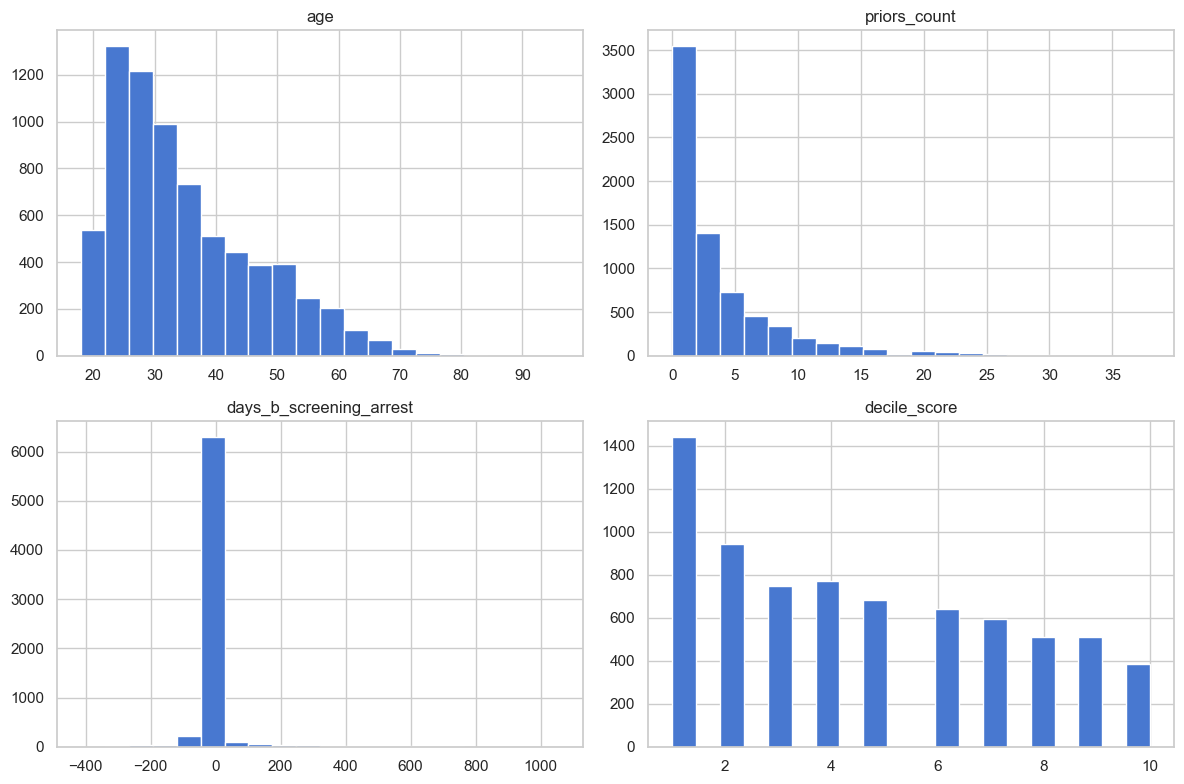

In [107]:
num_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

df[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

### 7.1 Boxplot outlier

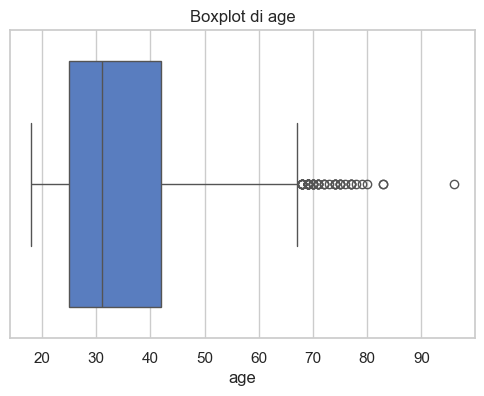

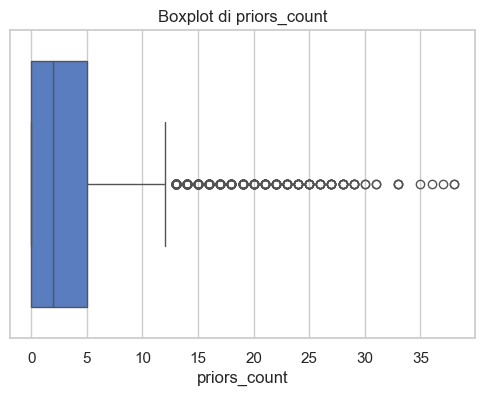

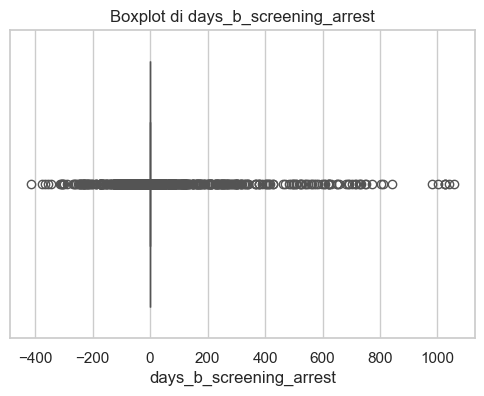

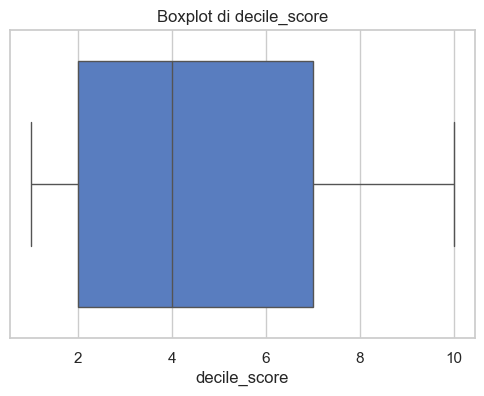

In [108]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot di {col}")
    plt.show()

___
## 8. Analisi esplorativa variabili categoriche

In [109]:
print('=== CATEGORICHE ===')
df.describe(include=['object', 'string'])

=== CATEGORICHE ===


,name,first,last,compas_screening_date,sex,dob,age_cat,race,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_charge_degree,c_charge_desc,r_case_number,r_charge_degree,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,score_text,screening_date,v_type_of_assessment,v_score_text,v_screening_date,in_custody,out_custody
count,7214,7214,7214,7214,7214,7214,7214,7214,6907,6907,7192,6055,1137,7214,7185,3471,3471,3471,3413,2316,2316,819,819,819,819,7214,7214,7214,7214,7214,7214,6978,6978
unique,7158,2800,3950,690,2,5452,3,6,6907,6880,7192,927,580,2,437,3471,10,1075,340,972,938,819,9,570,83,1,3,690,1,3,690,1156,1169
top,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,25 - 45,African-American,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,F,Battery,13009779CF10A,(M1),2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,Low,2013-02-20,Risk of Violence,Low,2013-02-20,2014-01-22,2020-01-01
freq,3,149,83,32,5819,5,4109,3696,1,3,1,26,9,4666,1156,1,1201,12,258,9,9,1,344,6,329,7214,3897,32,7214,4761,32,20,61


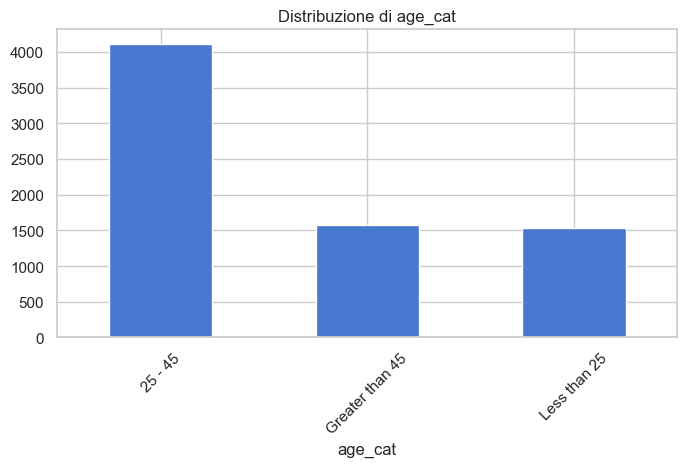

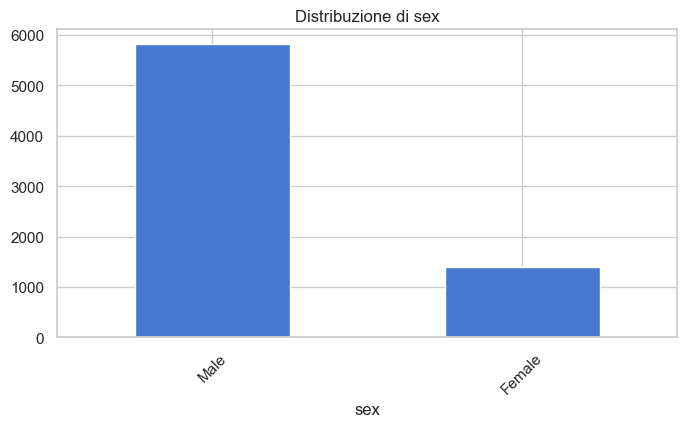

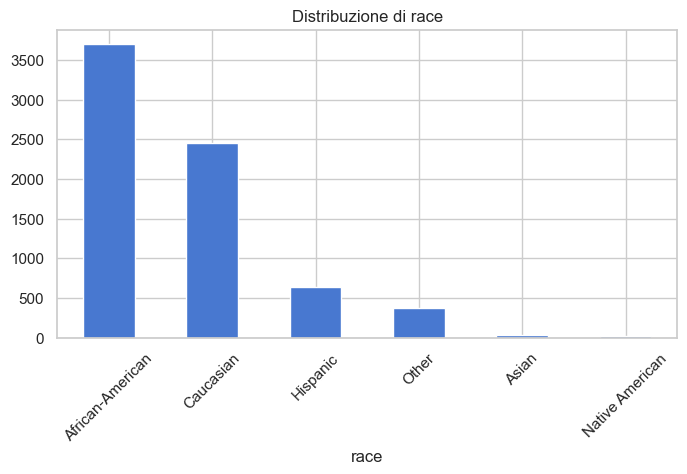

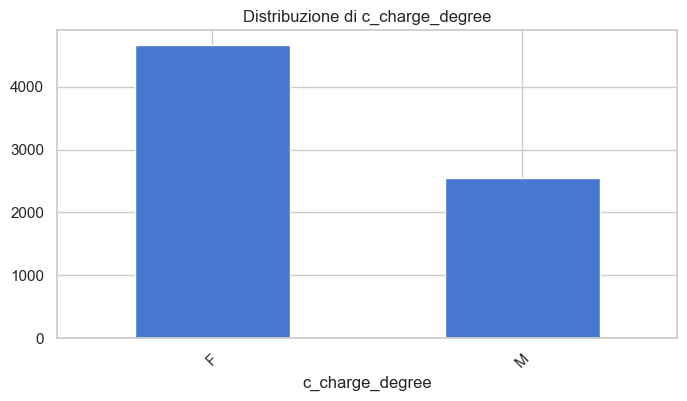

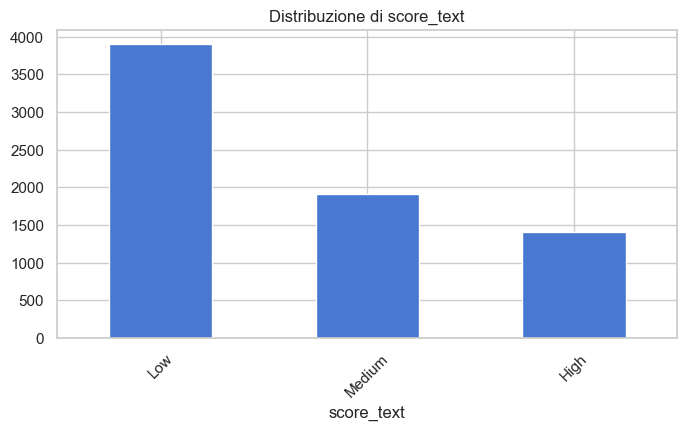

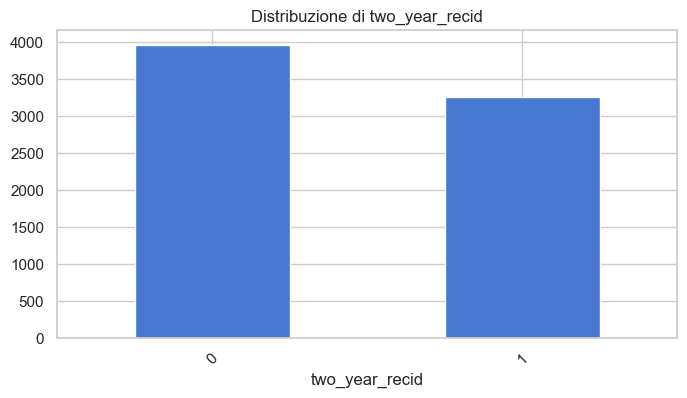

In [72]:
cat_cols = ["age_cat", "sex", "race", "c_charge_degree", "score_text", "two_year_recid"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df_clean[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribuzione di {col}")
    plt.xticks(rotation=45)
    plt.show()

In [110]:
cat_cols = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]

for col in cat_cols:
    print(f"\n===== {col} =====")
    print("Frequenze assolute:")
    print(df_clean[col].value_counts(dropna=False))
    print("\nFrequenze percentuali:")
    print(round(df_clean[col].value_counts(normalize=True, dropna=False) * 100, 2))


===== age_cat =====
Frequenze assolute:
age_cat
25 - 45            4109
Greater than 45    1576
Less than 25       1529
Name: count, dtype: int64

Frequenze percentuali:
age_cat
25 - 45           56.960
Greater than 45   21.850
Less than 25      21.190
Name: proportion, dtype: float64

===== sex =====
Frequenze assolute:
sex
Male      5819
Female    1395
Name: count, dtype: int64

Frequenze percentuali:
sex
Male     80.660
Female   19.340
Name: proportion, dtype: float64

===== race =====
Frequenze assolute:
race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64

Frequenze percentuali:
race
African-American   51.230
Caucasian          34.020
Hispanic            8.830
Other               5.230
Asian               0.440
Native American     0.250
Name: proportion, dtype: float64

===== c_charge_degree =====
Frequenze assolute:
c_charge_degree
F    4666
M    2548
N

controllo cardinalità

In [111]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df_clean[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
race,6
age_cat,3
score_text,3
sex,2
c_charge_degree,2


- quante modalità distinte ha ogni variabile
- se vi sono colonne con cardinalità eccessiva
- se alcune variabili richiederebbero una ricodifica

___
## 9. Ricerca delle categorie rare

ricerca delle categorie rare.  NON SO COSA FARCI...LE ACCORPO?

race_counts = df["race"].value_counts(normalize=True)
rare_races = race_counts[race_counts < 0.01].index

df["race"] = df["race"].replace(rare_races, "Other"). SE VOLESI ACCORPARLE E TRASORFMARLE IN OTHERS

In [112]:
threshold = 0.01

for col in cat_cols:
    freq = df_clean[col].value_counts(normalize=True, dropna=False)
    rare_categories = freq[freq < threshold]

    print(f"\nCategorie rare in {col} (meno dell'1%):")
    print(rare_categories if not rare_categories.empty else "Nessuna categoria rara")


Categorie rare in age_cat (meno dell'1%):
Nessuna categoria rara

Categorie rare in sex (meno dell'1%):
Nessuna categoria rara

Categorie rare in race (meno dell'1%):
race
Asian             0.004
Native American   0.002
Name: proportion, dtype: float64

Categorie rare in c_charge_degree (meno dell'1%):
Nessuna categoria rara

Categorie rare in score_text (meno dell'1%):
Nessuna categoria rara


Viene impostata una soglia del 1% e per ogni colonna categorica vengono individuate le categorie con frequenza inferiore a quella soglia.

___
## 10. Rilevamente outlier

In [113]:
def detect_outliers_iqr(df, cols, k=1.5):
   
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            'colonna': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'n_outliers': n_out,
            'pct_outliers': n_out / len(df) * 100
        })
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = detect_outliers_iqr(df_clean, num_cols)
display(outlier_report.style.bar(subset=['pct_outliers'], color='#f4a261').format({'pct_outliers': '{:.2f}%'}))

,colonna,lower_bound,upper_bound,n_outliers,pct_outliers
2,days_b_screening_arrest,-2.500000,1.500000,1397,19.37%
1,priors_count,-7.500000,12.500000,455,6.31%
0,age,-0.500000,67.500000,61,0.85%
3,decile_score,-5.500000,14.500000,0,0.00%


Per ogni variabile numerica la funzione stabilisce quali valori si trovano fuori dall’intervallo

Gli outlier vengono rilevati ma non rimossi automaticamente, poiché nel contesto giudiziario valori estremi possono rappresentare casi reali e informativamente rilevanti. La loro presenza viene quindi documentata e discussa, senza alterare il dataset finale destinato alle analisi successive.

___
## 11. Analisi delle correlazioni

In [114]:
corr_cols = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "two_year_recid"
]

corr_matrix = df_clean[corr_cols].corr(method="spearman")

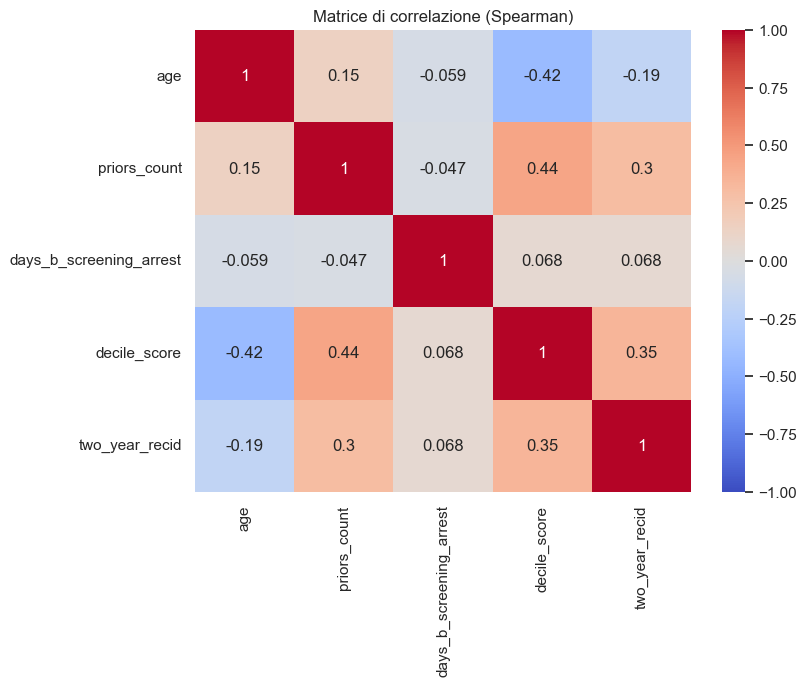

In [115]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Matrice di correlazione (Spearman)")
plt.show()

In [116]:
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlazione"]
corr_pairs["abs_corr"] = corr_pairs["correlazione"].abs()

corr_pairs.sort_values("abs_corr", ascending=False).head(10)

,feature_1,feature_2,correlazione,abs_corr
16,decile_score,priors_count,0.439,0.439
15,decile_score,age,-0.424,0.424
23,two_year_recid,decile_score,0.351,0.351
21,two_year_recid,priors_count,0.299,0.299
20,two_year_recid,age,-0.192,0.192
5,priors_count,age,0.147,0.147
22,two_year_recid,days_b_screening_arrest,0.068,0.068
17,decile_score,days_b_screening_arrest,0.068,0.068
10,days_b_screening_arrest,age,-0.059,0.059
11,days_b_screening_arrest,priors_count,-0.047,0.047


___
## 12. EDA per la varibile target

,two_year_recid,count,percent
0,0,3963,54.930
1,1,3251,45.070


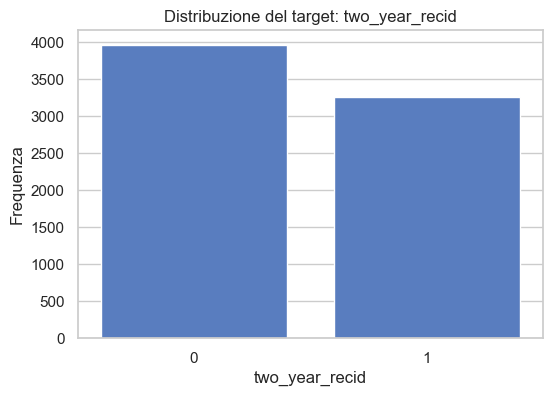

In [117]:
target_dist = (
    df_clean["two_year_recid"]
    .value_counts(dropna=False)
    .rename_axis("two_year_recid")
    .reset_index(name="count")
)
target_dist["percent"] = (target_dist["count"] / len(df_clean) * 100).round(2)

display(target_dist)

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="two_year_recid")
plt.title("Distribuzione del target: two_year_recid")
plt.xlabel("two_year_recid")
plt.ylabel("Frequenza")
plt.show()

___
## 13. Relazione variabile target e altre varibili

### 13.1 categoriche

Cosa mostra

Questa sezione consente di vedere come varia la quota di recidiva a seconda della categoria considerata.

two_year_recid,0,1
race,,
African-American,48.570,51.430
Asian,71.880,28.120
Caucasian,60.640,39.360
Hispanic,63.580,36.420
Native American,44.440,55.560
Other,64.720,35.280


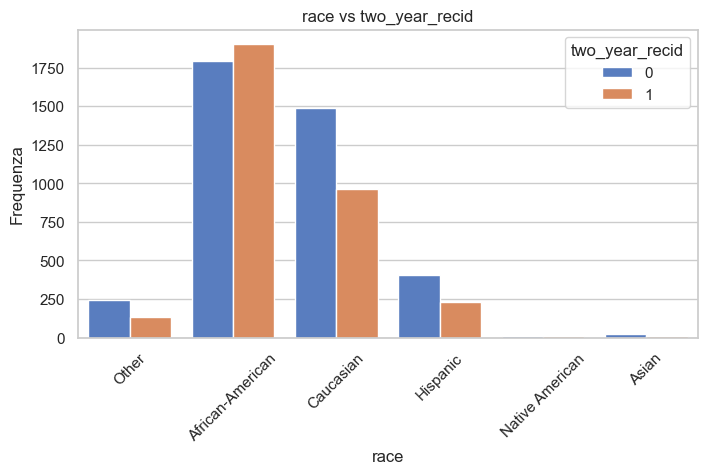

two_year_recid,0,1
sex,,
Female,64.300,35.700
Male,52.690,47.310


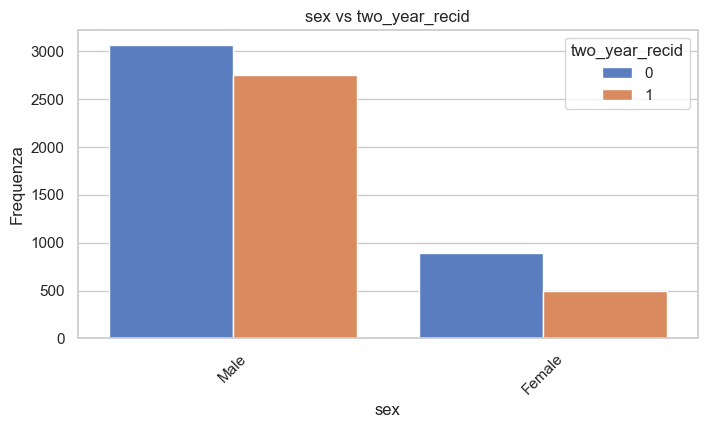

two_year_recid,0,1
age_cat,,
25 - 45,54.030,45.970
Greater than 45,68.400,31.600
Less than 25,43.490,56.510


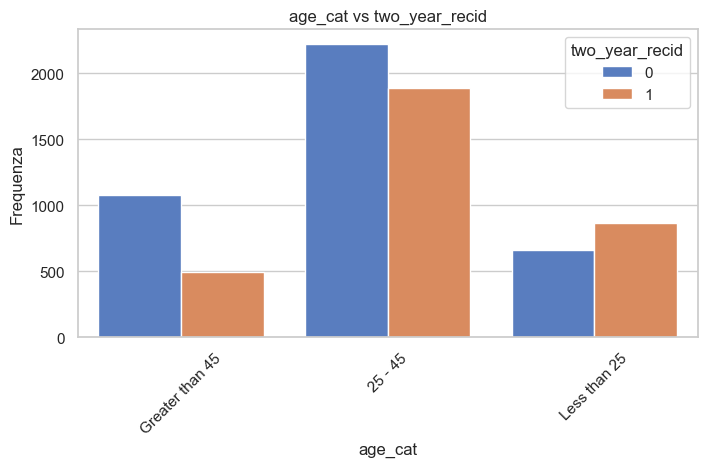

two_year_recid,0,1
c_charge_degree,,
F,51.090,48.910
M,61.970,38.030


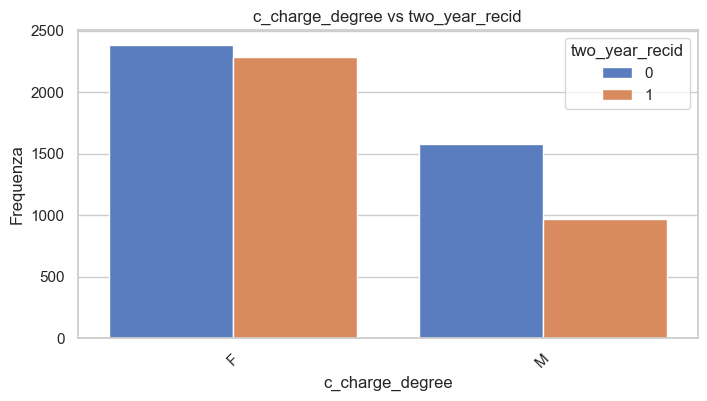

two_year_recid,0,1
score_text,,
High,28.650,71.350
Low,68.800,31.200
Medium,45.980,54.020


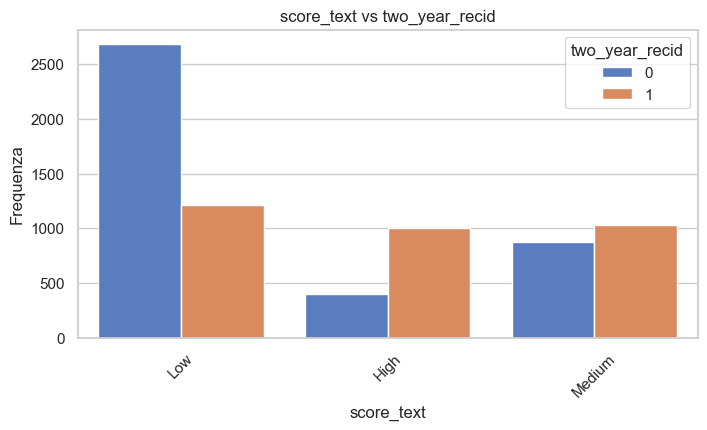

In [118]:
eda_cat_cols = ["race", "sex", "age_cat", "c_charge_degree", "score_text"]

for col in eda_cat_cols:
    summary = pd.crosstab(df_clean[col], df_clean["two_year_recid"], normalize="index") * 100
    display(summary.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_clean, x=col, hue="two_year_recid")
    plt.title(f"{col} vs two_year_recid")
    plt.xticks(rotation=45)
    plt.ylabel("Frequenza")
    plt.show()

### 13.2 numeriche

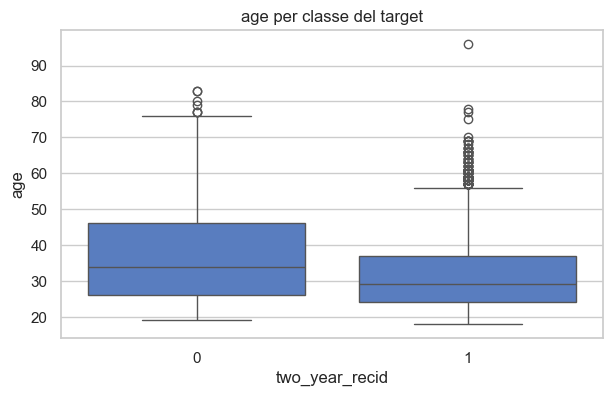

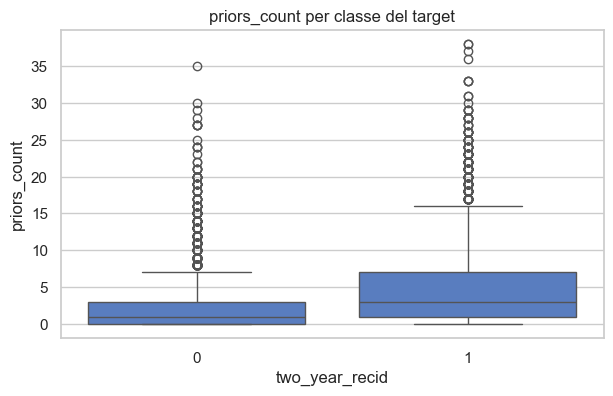

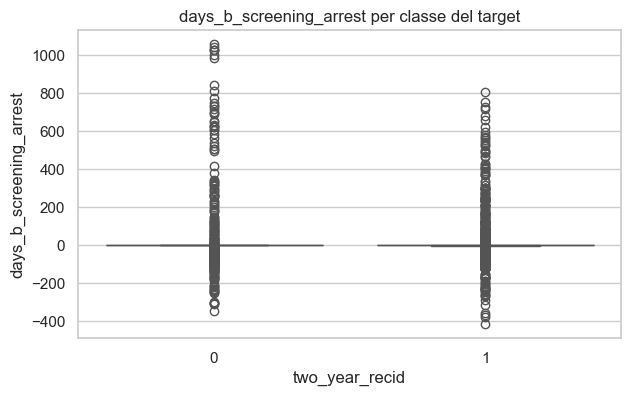

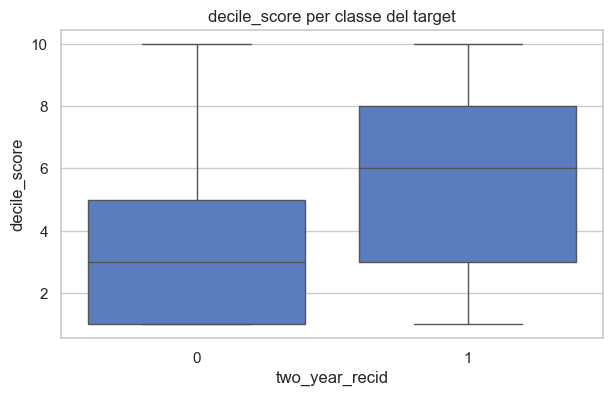

In [119]:
num_target_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

for col in num_target_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_clean, x="two_year_recid", y=col)
    plt.title(f"{col} per classe del target")
    plt.show()


___
## 14. analisi variabile target e variabili sensibili race e sex


=== Distribuzione di race ===


,count
race,
African-American,3696
Caucasian,2454
Hispanic,637
Other,377
Asian,32
Native American,18



Percentuali di two_year_recid per race:


two_year_recid,0,1
race,,
African-American,48.570,51.430
Asian,71.880,28.120
Caucasian,60.640,39.360
Hispanic,63.580,36.420
Native American,44.440,55.560
Other,64.720,35.280


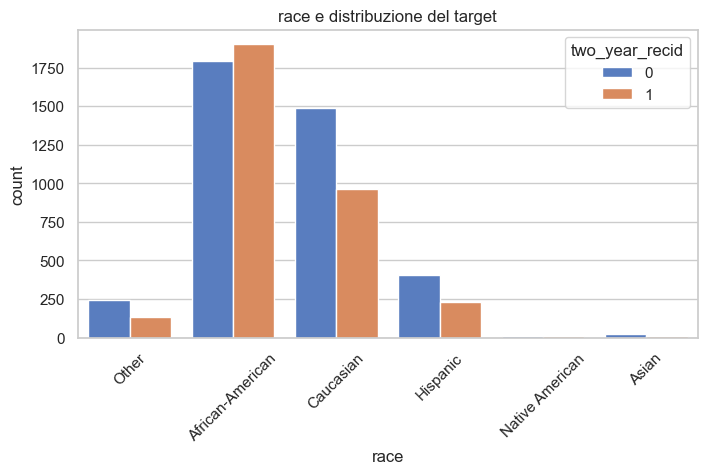


=== Distribuzione di sex ===


,count
sex,
Male,5819
Female,1395



Percentuali di two_year_recid per sex:


two_year_recid,0,1
sex,,
Female,64.300,35.700
Male,52.690,47.310


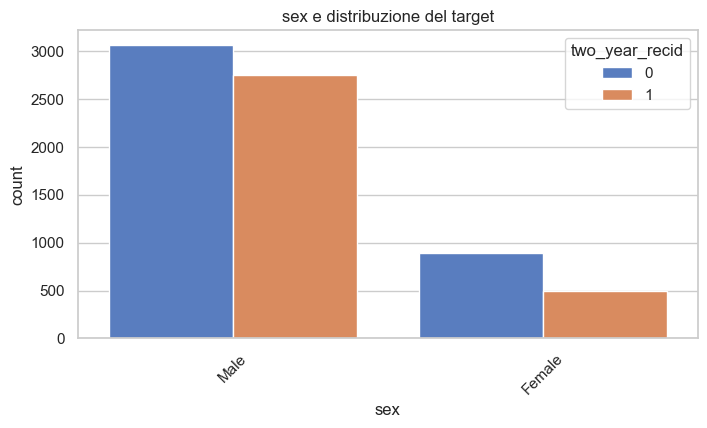

In [120]:
for sensitive_col in ["race", "sex"]:
    print(f"\n=== Distribuzione di {sensitive_col} ===")
    display(df_clean[sensitive_col].value_counts(dropna=False).to_frame("count"))

    recid_by_group = pd.crosstab(
        df_clean[sensitive_col],
        df_clean["two_year_recid"],
        normalize="index"
    ) * 100
    print(f"\nPercentuali di two_year_recid per {sensitive_col}:")
    display(recid_by_group.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_clean, x=sensitive_col, hue="two_year_recid")
    plt.title(f"{sensitive_col} e distribuzione del target")
    plt.xticks(rotation=45)
    plt.show()

___
## 15. analisi score compas e gruppi sensibili race e sex 


Distribuzione percentuale di score_text per race:


score_text,High,Low,Medium
race,,,
African-American,27.730,41.180,31.090
Asian,9.380,75.000,15.620
Caucasian,11.250,65.200,23.550
Hispanic,10.520,70.170,19.310
Native American,33.330,33.330,33.330
Other,6.900,79.050,14.060


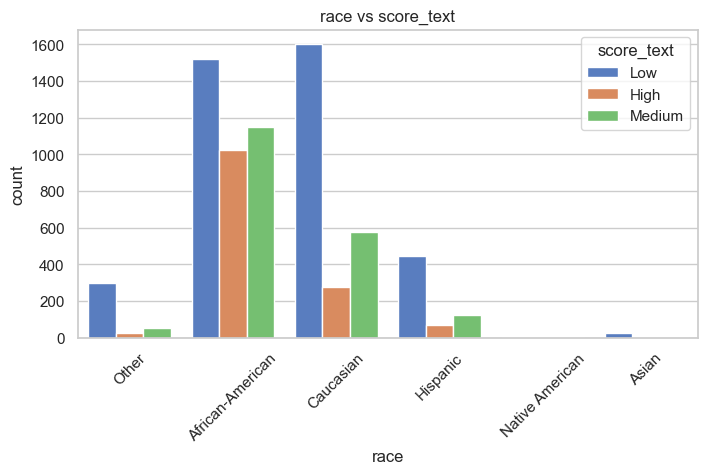


Distribuzione percentuale di score_text per sex:


score_text,High,Low,Medium
sex,,,
Female,13.620,57.630,28.750
Male,20.850,53.150,26.000


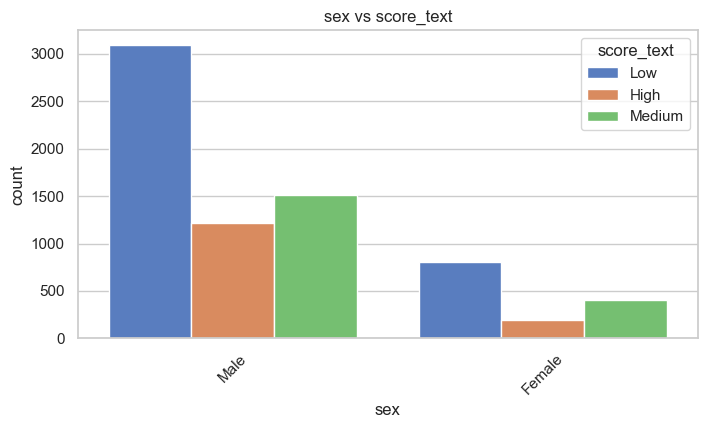

In [121]:
for sensitive_col in ["race", "sex"]:
    score_summary = pd.crosstab(
        df_clean[sensitive_col],
        df_clean["score_text"],
        normalize="index"
    ) * 100

    print(f"\nDistribuzione percentuale di score_text per {sensitive_col}:")
    display(score_summary.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_clean, x=sensitive_col, hue="score_text")
    plt.title(f"{sensitive_col} vs score_text")
    plt.xticks(rotation=45)
    plt.show()

___
## 16. riassunto finale

In [ ]:
df_nodup = df.drop_duplicates()
df_selected = df_nodup[cols].copy()

shape_summary = pd.DataFrame({
    "fase": [
        "Dataset originale",
        "Dopo rimozione duplicati",
        "Dopo selezione variabili",
        "Dopo filtro ProPublica / dataset finale"
    ],
    "n_righe": [
        df.shape[0],
        df_nodup.shape[0],
        df_selected.shape[0],
        df_clean.shape[0]
    ],
    "n_colonne": [
        df.shape[1],
        df_nodup.shape[1],
        df_selected.shape[1],
        df_clean.shape[1]
    ]
})

display(shape_summary)

,fase,n_righe,n_colonne
0,Dataset originale,7214,53
1,Dopo rimozione duplicati,7214,53
2,Dopo selezione variabili,7214,11
3,Dopo filtro ProPublica / dataset finale,7214,53


In [ ]:
# Esportazione dataset finale per Orange
output_path = "compas_clean_for_orange.csv"

df_clean.to_csv(output_path, index=False)

print(f"Dataset esportato correttamente in: {output_path}")
print(f"Shape finale: {df_clean.shape}")
df_clean.head()

: 

In [ ]:
# Dataset finale per Orange
df_final = df_filtered.copy()

print("Shape dopo filtro ProPublica:", df_filtered.shape)

print("Dataset finale pronto per l'esportazione")
print("Shape:", df_final.shape)
display(df_final.head())

Shape dopo filtro ProPublica: (6172, 11)
Dataset finale pronto per l'esportazione
Shape: (6172, 11)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,is_recid,score_text,decile_score,two_year_recid
0,69,Greater than 45,Male,Other,0,-1.000,F,0,Low,1,0
1,34,25 - 45,Male,African-American,0,-1.000,F,1,Low,3,1
2,24,Less than 25,Male,African-American,4,-1.000,F,1,Low,4,1
5,44,25 - 45,Male,Other,0,0.000,M,0,Low,1,0
6,41,25 - 45,Male,Caucasian,14,-1.000,F,1,Medium,6,1


In [125]:
# Esportazione del dataset finale per Orange
nome_file = "compas_final_orange.csv"
df_final.to_csv(nome_file, index=False)

print(f"File esportato correttamente: {nome_file}")
print(f"Dimensioni del dataset esportato: {df_final.shape}")

File esportato correttamente: compas_final_orange.csv
Dimensioni del dataset esportato: (6172, 11)
